In [2]:
import sys
!{sys.executable} -m pip install langgraph

  Using cached langgraph-1.2.9-py3-none-any.whl.metadata (4.9 kB)
  Using cached langchain_core-1.5.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached langgraph_checkpoint-4.1.1-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached langgraph_sdk-0.4.2-py3-none-any.whl.metadata (3.6 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain_protocol-0.0.18-py3-none-any.whl.metadata (2.4 kB)
  Using cached langsmith-0.10.10-py3-none-any.whl.metadata (22 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached jsonpointer-3.1.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.14.2-py3-none-any.whl.metadata (4.6 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached requests-2.34.2

In [5]:
import sys

!{sys.executable} -m pip install -U \
pydantic \
langgraph \
langgraph-checkpoint \
langgraph-checkpoint-postgres \
langchain \
langchain-core \
langchain-community \
langchain-groq \
python-dotenv \
psycopg[binary] \
jupyter \
ipykernel

  Using cached langgraph_checkpoint_postgres-3.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached langchain-1.3.14-py3-none-any.whl.metadata (6.1 kB)
  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached langchain_groq-1.1.3-py3-none-any.whl.metadata (2.9 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached psycopg-3.3.4-py3-none-any.whl.metadata (4.3 kB)
  Using cached psycopg_pool-3.3.1-py3-none-any.whl.metadata (2.8 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached langchain_classic-1.0.8-py3-none-any.whl.metadata (5.1 kB)
  Using cached pydantic_settings-2.14.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached aiohappyeyeballs-2.7.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cache

In [6]:
import langgraph
import langchain
import langchain_groq
import psycopg
import dotenv

print("Everything installed successfully!")

Everything installed successfully!


In [7]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
import os
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

import psycopg
from psycopg.rows import dict_row
from langgraph.checkpoint.postgres import PostgresSaver
from dotenv import load_dotenv

load_dotenv()

True

In [8]:
def get_database_url():
    database_url = os.getenv("DATABASE_URL")

    if not database_url:
        raise ValueError(
            "DATABASE_URL is missing. Please add your Render PostgreSQL External Database URL to .env"
        )

    if "sslmode=" not in database_url:
        separator = "&" if "?" in database_url else "?"
        database_url = f"{database_url}{separator}sslmode=require"

    return database_url

In [10]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is missing. Please add it to your .env file.")

In [11]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [12]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [13]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [14]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY
)

In [15]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [16]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [17]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [18]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [19]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

In [20]:
# =========================
# PostgreSQL Checkpointer
# =========================
DATABASE_URL = get_database_url()

_conn = psycopg.connect(
    DATABASE_URL,
    autocommit=True,
    row_factory=dict_row
)

checkpointer = PostgresSaver(_conn)
checkpointer.setup()

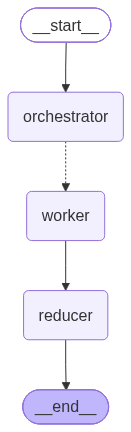

In [21]:
app = g.compile(checkpointer=checkpointer)

app

In [22]:
config = {
        "configurable": {
            "thread_id": "test_thread_id"
        }
    }

In [23]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []}, config=config)

In [24]:
out

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self Attention in Deep Learning', tasks=[Task(id=1, title='Introduction to Self Attention', brief='Define self attention, its importance, and applications in deep learning'), Task(id=2, title='Mechanics of Self Attention', brief='Explain the mathematical formulation and step-by-step process of self attention'), Task(id=3, title='Types of Self Attention', brief='Discuss different variants of self attention, such as local self attention and global self attention'), Task(id=4, title='Self Attention in Sequence-to-Sequence Models', brief='Describe how self attention is used in sequence-to-sequence models, such as transformers'), Task(id=5, title='Advantages and Limitations of Self Attention', brief='Discuss the benefits and drawbacks of using self attention in deep learning models'), Task(id=6, title='Real-World Applications of Self Attention', brief='Provide examples of real-world applications that utilize